<a href="https://www.kaggle.com/code/subhadiphensh/digit-recognition-mlp-on-mnist?scriptVersionId=291389902" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
!pip install "protobuf<4" --no-deps -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.1 MB/s eta 0:00:00a 0:00:01


In [2]:
import os

import math
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf

import warnings
warnings.filterwarnings('ignore')

2026-01-12 06:09:34.937970: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768198175.114687      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768198175.167531      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
print(f"Python Version : {platform.python_version()}")
print(f'Tensorflow Version : {tf.__version__}')
print(f"Keras Version : {tf.keras.__version__}")

Python Version : 3.11.13
Tensorflow Version : 2.18.0
Keras Version : 3.8.0


In [4]:
!nvidia-smi

Mon Jan 12 06:09:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
mnist_dataset = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist_dataset.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape}")

X_train : (60000, 28, 28)
y_train : (60000,)
X_test : (10000, 28, 28)
y_test : (10000,)


In [7]:
pd.set_option("display.max_columns", None)

In [8]:
pd.DataFrame(X_train[0])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,3,18,18,18,126,136,175,26,166,255,247,127,0,0,0,0
6,0,0,0,0,0,0,0,0,30,36,94,154,170,253,253,253,253,253,225,172,253,242,195,64,0,0,0,0
7,0,0,0,0,0,0,0,49,238,253,253,253,253,253,253,253,253,251,93,82,82,56,39,0,0,0,0,0
8,0,0,0,0,0,0,0,18,219,253,253,253,253,253,198,182,247,241,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,80,156,107,253,253,205,11,0,43,154,0,0,0,0,0,0,0,0,0,0


In [9]:
plt.style.use('dark_background')

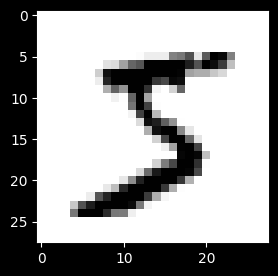

In [10]:
plt.figure(figsize = (3, 3))
plt.imshow(X_train[0], cmap = plt.cm.binary)
plt.show()

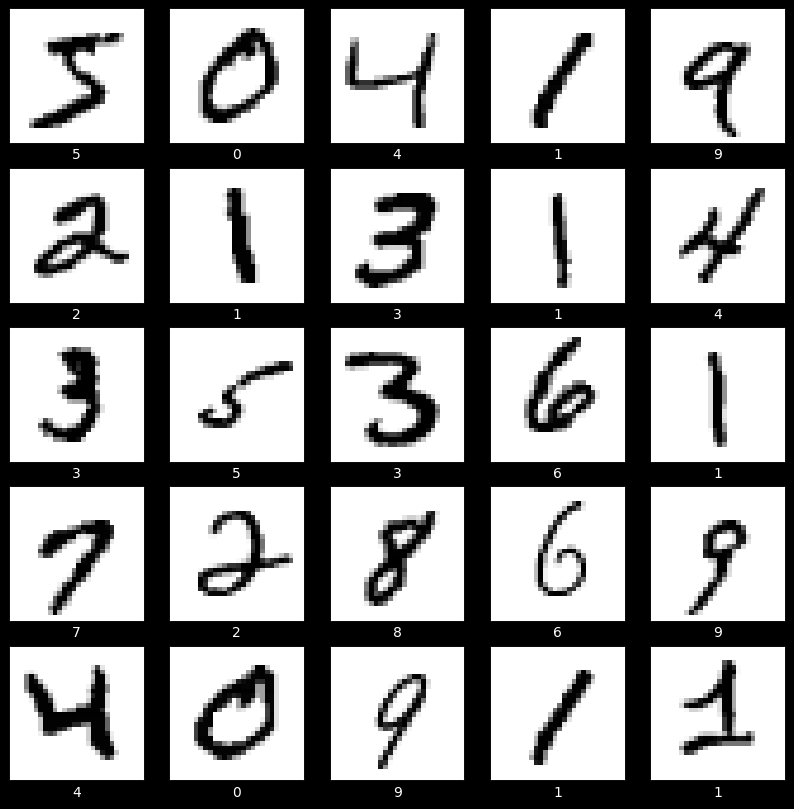

In [11]:
numbers_to_display = 25
num_cells = math.ceil(math.sqrt(numbers_to_display))
plt.figure(figsize = (10, 10))

for i in range(numbers_to_display):
    plt.subplot(num_cells, num_cells, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(True)
    plt.imshow(X_train[i], cmap = plt.cm.binary)
    plt.xlabel(y_train[i])

plt.show()

In [12]:
X_train_normalized = X_train / 255.
X_test_normalized = X_test / 255

In [13]:
with pd.option_context("display.float_format", "{:,.3f}".format):
    display(pd.DataFrame(X_train_normalized[0]))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.012,0.071,0.071,0.071,0.494,0.533,0.686,0.102,0.651,1.000,0.969,0.498,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.118,0.141,0.369,0.604,0.667,0.992,0.992,0.992,0.992,0.992,0.882,0.675,0.992,0.949,0.765,0.251,0.000,0.000,0.000,0.000
7,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.192,0.933,0.992,0.992,0.992,0.992,0.992,0.992,0.992,0.992,0.984,0.365,0.322,0.322,0.220,0.153,0.000,0.000,0.000,0.000,0.000
8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.071,0.859,0.992,0.992,0.992,0.992,0.992,0.776,0.714,0.969,0.945,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.314,0.612,0.420,0.992,0.992,0.804,0.043,0.000,0.169,0.604,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


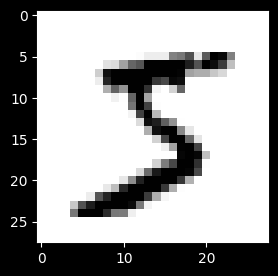

In [14]:
plt.figure(figsize = (3, 3))
plt.imshow(X_train_normalized[0], cmap = plt.cm.binary)
plt.show()

## **Model Building**

In [15]:
def create_model(X_train):
    model = tf.keras.models.Sequential(
        [
            tf.keras.layers.Flatten(input_shape = X_train.shape[1 : ]),
            tf.keras.layers.Dense(
                units = 128,
                activation = tf.keras.activations.relu,
                kernel_regularizer = tf.keras.regularizers.l2(0.002)
            ),
            tf.keras.layers.Dense(
                units = 128,
                activation = tf.keras.activations.relu,
                kernel_regularizer = tf.keras.regularizers.l2(0.002)
            ),
            tf.keras.layers.Dense(
                units = 10,
                activation = tf.keras.activations.softmax
            )
        ]
    )

    adam_optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001)

    model.compile(
        optimizer = adam_optimizer,
        loss = tf.keras.losses.sparse_categorical_crossentropy,
        metrics = ['accuracy']
    )

    return model.summary(), model

In [16]:
_ , model = create_model(X_train_normalized)

I0000 00:00:1768198190.794579      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768198190.795190      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

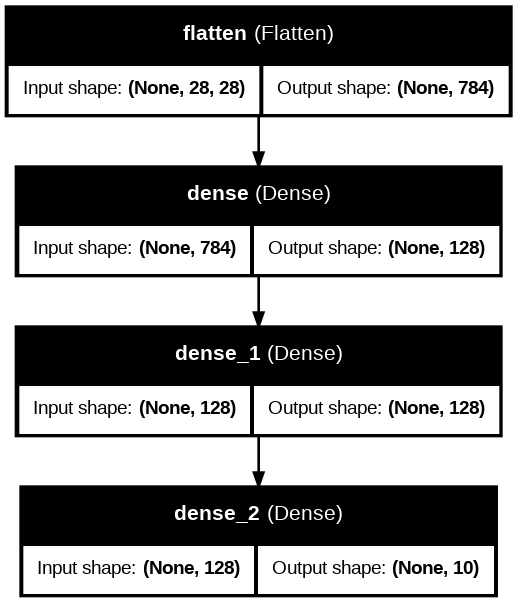

In [17]:
tf.keras.utils.plot_model(
    model,
    show_shapes = True,
    show_layer_names = True,
    dpi = 96
)

In [18]:
training_history = model.fit(
    X_train_normalized,
    y_train,
    epochs = 10,
    validation_data = (X_test_normalized, y_test)
)

Epoch 1/10


I0000 00:00:1768198194.225140     117 service.cc:148] XLA service 0x783880005900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768198194.225814     117 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1768198194.225836     117 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1768198194.432156     117 cuda_dnn.cc:529] Loaded cuDNN version 90300


  78/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5574 - loss: 2.0950

I0000 00:00:1768198195.440240     117 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8781 - loss: 0.7681 - val_accuracy: 0.9481 - val_loss: 0.3359
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9534 - loss: 0.3138 - val_accuracy: 0.9585 - val_loss: 0.2685
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9625 - loss: 0.2565 - val_accuracy: 0.9660 - val_loss: 0.2309
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9649 - loss: 0.2369 - val_accuracy: 0.9670 - val_loss: 0.2219
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9671 - loss: 0.2195 - val_accuracy: 0.9633 - val_loss: 0.2207
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9691 - loss: 0.2097 - val_accuracy: 0.9704 - val_loss: 0.2000
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9690 - loss: 0.1983 - val_accuracy: 0.9637 - val_loss: 0.2111
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9698 - loss: 0.1932 - val_accurac

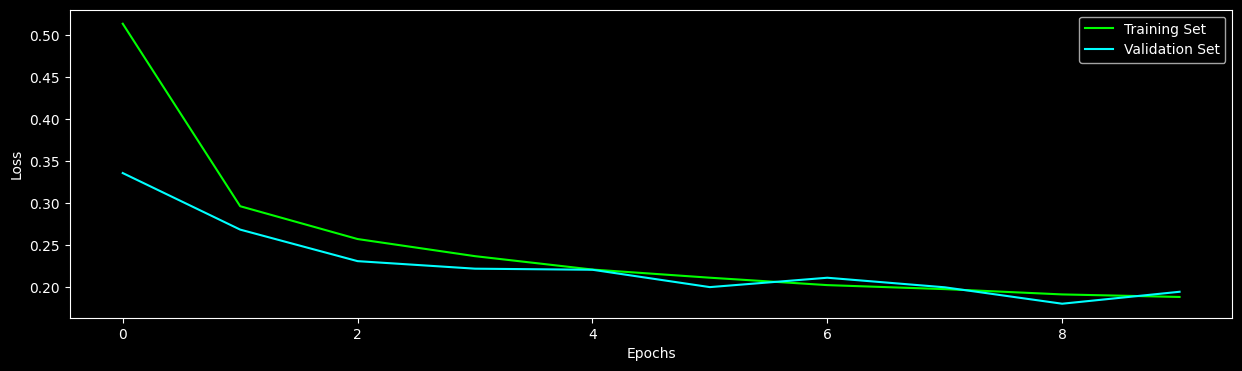

In [19]:
plt.figure(figsize = (15, 4))
plt.plot(training_history.history['loss'], label = 'Training Set', color = 'Lime')
plt.plot(training_history.history['val_loss'], label = 'Validation Set', color = 'cyan')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

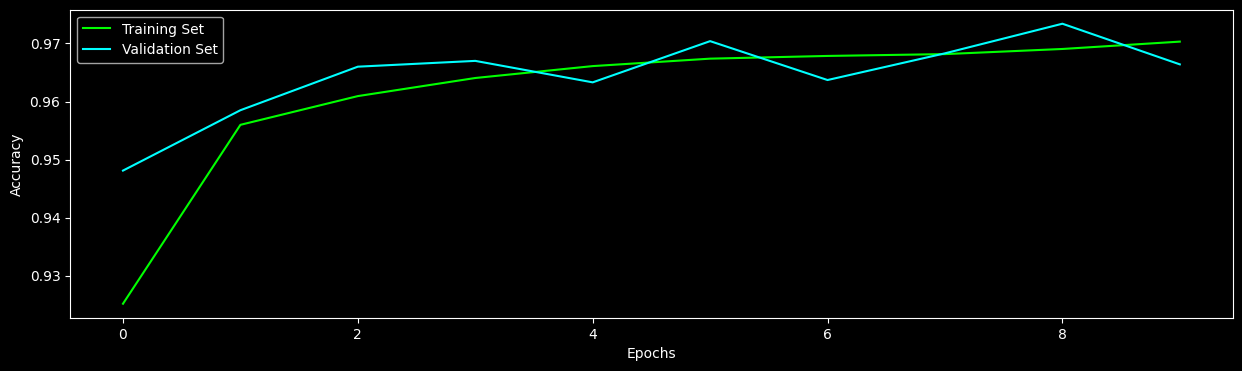

In [20]:
plt.figure(figsize = (15, 4))
plt.plot(training_history.history['accuracy'], label = 'Training Set', color = 'Lime')
plt.plot(training_history.history['val_accuracy'], label = 'Validation Set', color = 'cyan')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [21]:
train_loss, train_accuracy = model.evaluate(X_train_normalized, y_train)

print('Training loss : ', train_loss)
print('Training accuracy : ', train_accuracy)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9751 - loss: 0.1770
Training loss :  0.17648807168006897
Training accuracy :  0.9746833443641663


In [23]:
validation_loss, validation_accuracy = model.evaluate(X_test_normalized, y_test)

print('Validation loss : ', validation_loss)
print('Validation accuracy : ', validation_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9611 - loss: 0.2144
Validation loss :  0.1944282501935959
Validation accuracy :  0.9664000272750854


In [24]:
model.save("Digit_Recognition_MLP.keras")

In [25]:
loaded_model = tf.keras.models.load_model("/kaggle/working/Digit_Recognition_MLP.keras")

## **Do Prediction**

In [26]:
predictions_one_hot = loaded_model.predict([X_test_normalized])

print(f"Predictions_One_Hot : {predictions_one_hot.shape}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predictions_One_Hot : (10000, 10)


In [27]:
pd.DataFrame(predictions_one_hot)

,0,1,2,3,4,5,6,7,8,9
0,1.472424e-06,3.420753e-06,2.048280e-04,4.132586e-04,3.325142e-09,9.725824e-06,1.259335e-10,9.993495e-01,0.000003,1.471097e-05
1,1.054872e-03,1.032018e-03,9.930970e-01,2.439380e-03,8.040782e-08,1.705426e-04,5.082636e-04,7.419198e-07,0.001697,3.911857e-08
2,1.272510e-04,9.678101e-01,2.673461e-03,9.848614e-04,2.691590e-03,1.364964e-03,3.784739e-03,2.341435e-03,0.018124,9.760557e-05
3,9.995071e-01,1.715874e-06,2.109440e-04,1.611831e-06,2.770612e-05,9.488549e-06,2.030443e-04,1.406249e-05,0.000002,2.199155e-05
4,1.296634e-04,1.348029e-05,2.171631e-04,5.766629e-06,9.965406e-01,2.045235e-05,2.228357e-05,7.880304e-04,0.000008,2.254901e-03
...,...,...,...,...,...,...,...,...,...,...
9995,3.727669e-07,2.573073e-04,9.996552e-01,7.184635e-05,1.552362e-12,2.377729e-07,4.180925e-08,7.783239e-06,0.000007,2.050886e-11
9996,1.148582e-05,2.829457e-05,2.652211e-04,9.959574e-01,8.532571e-08,1.394214e-03,3.386325e-09,1.022984e-05,0.000890,1.442787e-03
9997,4.009263e-08,1.979764e-05,1.798815e-08,1.355167e-08,9.999206e-01,1.481127e-07,1.343682e-07,3.608530e-05,0.000007,1.595373e-05
9998,6.977833e-05,1.626958e-06,3.299421e-06,1.413632e-04,1.999333e-07,9.992560e-01,6.969553e-05,2.488159e-06,0.000454,1.307974e-06


In [28]:
predictions = np.argmax(predictions_one_hot, axis = 1)
pd.DataFrame(predictions)

,0
0,7
1,2
2,1
3,0
4,4
...,...
9995,2
9996,3
9997,4
9998,5


In [29]:
print(predictions[0])

7


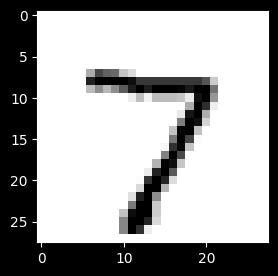

In [30]:
plt.figure(figsize = (3, 3))
plt.imshow(X_test_normalized[0], cmap = plt.cm.binary)
plt.show()

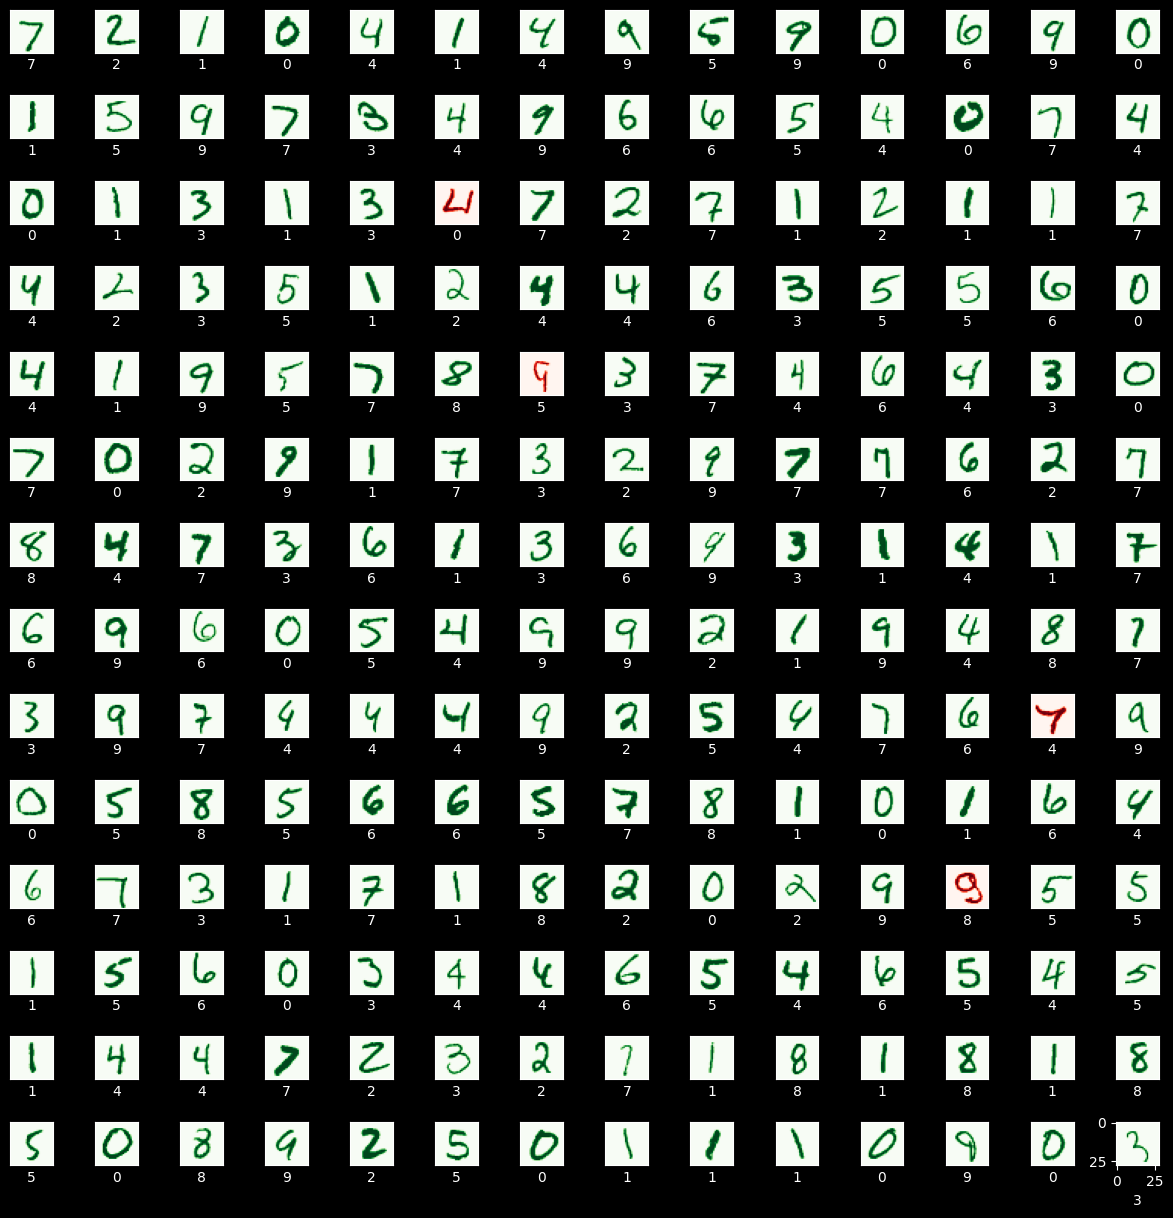

In [31]:
numbers_to_display = 196
num_cells = math.ceil(math.sqrt(numbers_to_display))
plt.figure(figsize = (15, 15))

for plot_index in range(numbers_to_display):
    predicted_label = predictions[plot_index]
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    color_map = 'Greens' if predicted_label == y_test[plot_index] else 'Reds'
    plt.subplot(num_cells, num_cells, plot_index + 1)
    plt.imshow(X_test_normalized[plot_index], cmap = color_map)
    plt.xlabel(predicted_label)

plt.subplots_adjust(hspace = 1, wspace = 0.5)
plt.show()

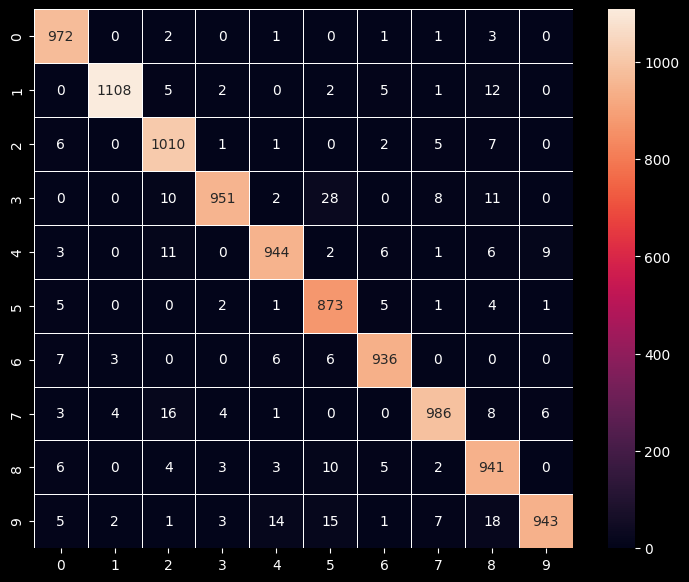

In [32]:
confusion_matrix = tf.math.confusion_matrix(y_test, predictions)
f, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    confusion_matrix,
    annot = True,
    linewidths = .5,
    fmt = "d",
    square = True,
    ax = ax
)

plt.show()

In [33]:
import cv2
import requests


--- Contoured Image ---


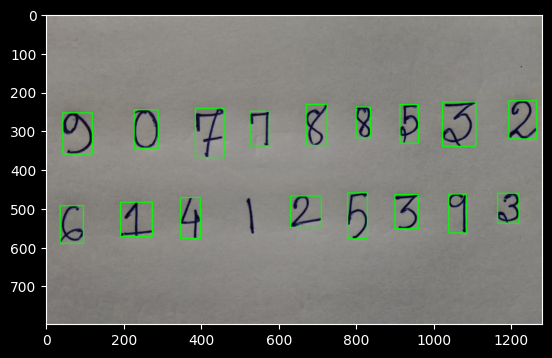


------------------- Making Predictions ----------------------


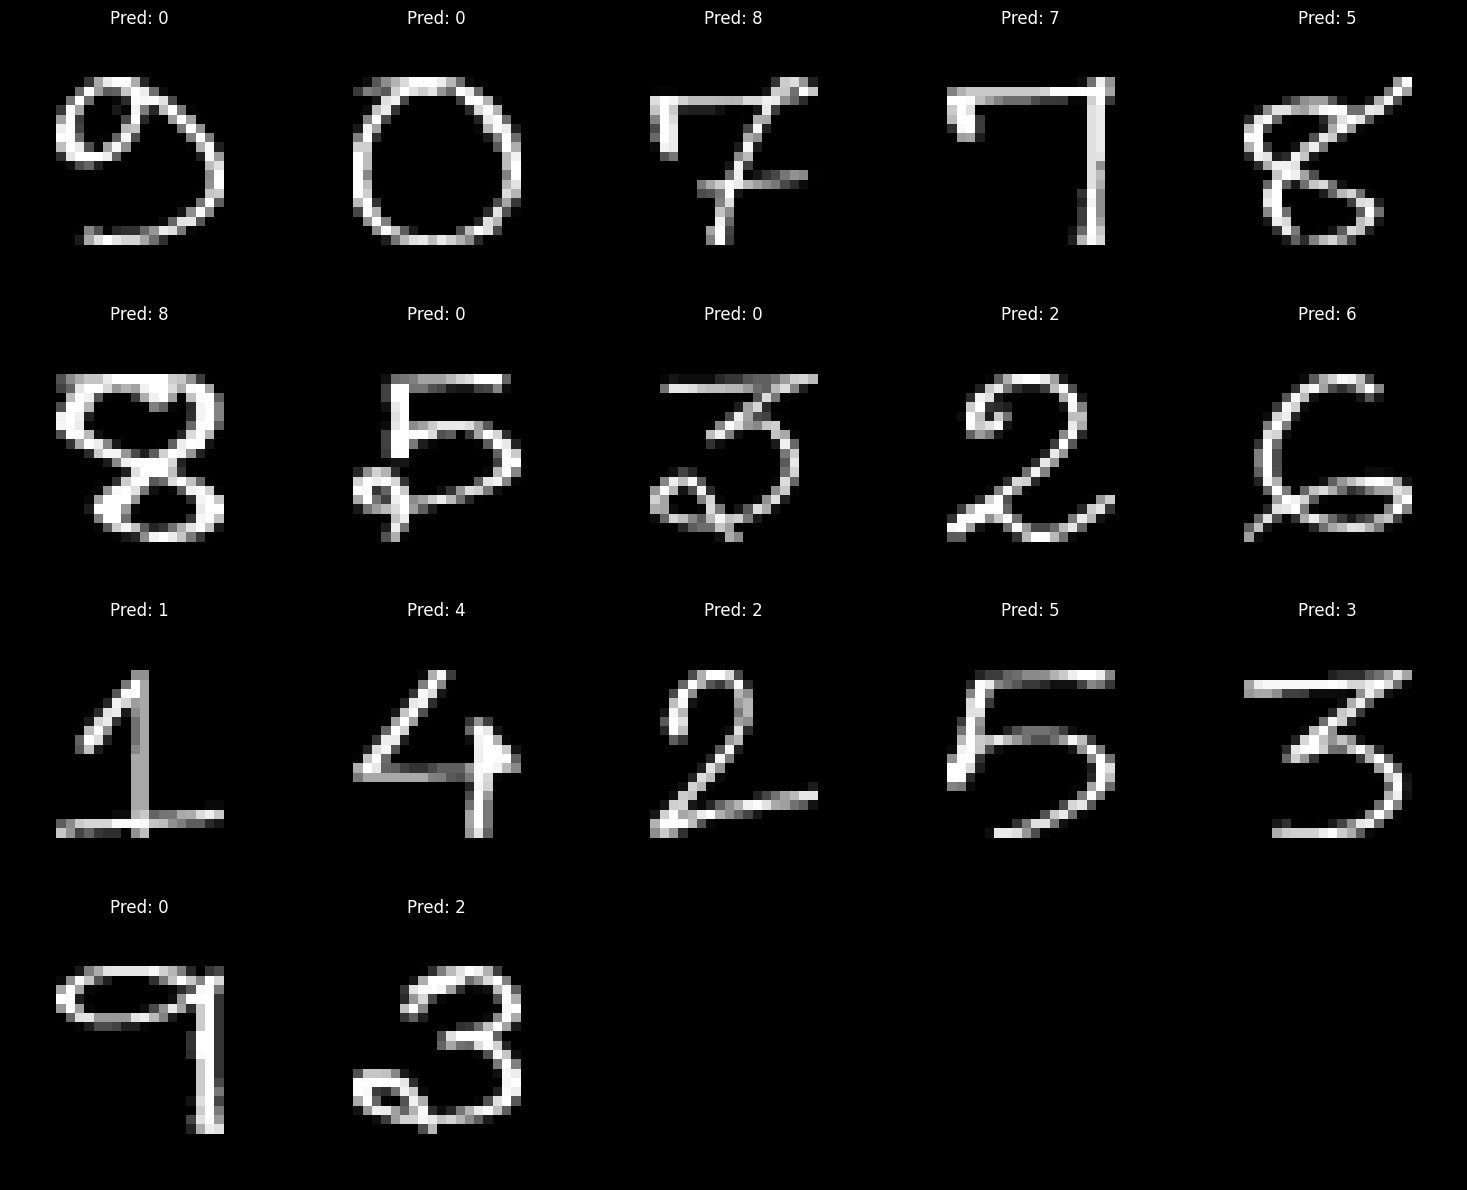

In [34]:
URL = "https://raw.githubusercontent.com/07subhadip/CNN-Projects/main/MNIST_input.jpg"

try:
    response = requests.get(URL)
    response.raise_for_status() 

    image_array = np.frombuffer(response.content, np.uint8)
    image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

    if image is not None:
        image = cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)
    else:
        print("Error: Image decoded as None. Check if the URL points to a valid image file.")

except Exception as e:
    print("Error loading image :", e)
    image = None


if image is None:
    print("FATAL ERROR: Image NOT loaded.")
else:
    grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    ret, thresh = cv2.threshold(grey, 75, 255, cv2.THRESH_BINARY_INV)

    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contoured_image = image.copy()
    digit_boxes = []

    for c in contours:
        x, y, w, h = cv2.boundingRect(c)

        if w < 20 or h < 20:
            continue

        cv2.rectangle(contoured_image, (x, y), (x+w, y+h), (0,255,0), 2)

        digit = thresh[y:y+h, x:x+w]
        resized_digit = cv2.resize(digit, (18, 18), interpolation=cv2.INTER_AREA)
        padded_digit = np.pad(resized_digit, ((5,5),(5,5)), "constant", constant_values=0)
        normalized_digit = padded_digit / 255.0

        digit_boxes.append((x, y, normalized_digit))

    print("\n--- Contoured Image ---")
    plt.imshow(cv2.cvtColor(contoured_image, cv2.COLOR_BGR2RGB))
    plt.show()

    print("\n------------------- Making Predictions ----------------------")

    digit_boxes = sorted(digit_boxes, key=lambda b: (b[1]//100, b[0]))

    preprocessed_digits = [d[2] for d in digit_boxes]
    num_digits = len(preprocessed_digits)

    cols = 5
    rows = math.ceil(num_digits / cols)

    plt.figure(figsize=(15, rows * 3))

    for i, digit in enumerate(preprocessed_digits):
        input_tensor = digit.reshape(1, 28, 28, 1)
        prediction = loaded_model.predict(input_tensor, verbose=0) 
        final_output = np.argmax(prediction)

        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(digit.reshape(28, 28), cmap='gray')
        ax.set_title(f"Pred: {final_output}", fontsize=12)
        ax.axis('off')

    plt.tight_layout()
    plt.show()